## Yapay Sinir Ağları (ANN)

1. Bu çalışmada, MNIST el yazısı rakamları içeren veri setini kullanarak yapay sinir ağı (ann) modeli ile sınıflandırma yapmak
Model, rakamları (0-9) doğru şekilde tanımlamayı öğrenir ve başarım metrikleri ile değerlendirilir.

Veri seti:

- mnist, 28x28 piksel boyutlarında, el yazısı ile yazılmış 0-9 arasında toplam 70000 görüntü var
- 60000 training veri seti, 10000 test veri seti.

Plan/Program:

1. veri setinin yüklenmesi ve örnek görüntülerin görselleştirilmesi
2. normalizasyon (0-1 arasına ölçeklendirme)
3. Etiketlerin one-hot encoding yöntemiyle kategorik hale getirilmesi
4. yapay sinir ağı mimarisinin oluşturulması
5. modelin derlenmesi
6. erken durdurma (early stopping) ve en iyi modelin kaydedilmesi (model check point) callback lerinin tanımlanması
7. Eğitim ve doğrulama metriklerinin görselleştirilmesi
8. Kurulumlar: pip install tensorflow matplotlib

### Not: Tensorflow, derin öğrenme için kullanılan en önemli kütüphanedir.

In [1]:
# gerekli kütüphanelerin içeri akarılması
from tensorflow.keras.datasets import mnist # veri seti
from tensorflow.keras.utils import to_categorical # kategorik verilere çevirme one hot encoding
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential # sirali model, ann ü bunun üzerine inşa et
from tensorflow.keras.layers import Dense # bağlı katman

import matplotlib.pyplot as plt

2026-05-20 17:53:29.326494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779299609.518240      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779299609.572486      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779299610.036607      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779299610.036649      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779299610.036653      57 computation_placer.cc:177] computation placer alr

### Not: Tensforflow kütüphanesinde veri yükleme adımı bu şekilde gerçekleşiyor. Her kütüphanenin syntax'ı farklıdır. Bu kütüphane (x_train, y_train), (x_test, y_test) şeklinde bölmeyi tercih etmiş.

In [2]:
# veri setini eğitim ve test olmak üzere ayrı ayrı yükle
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [4]:
y_train[0]

np.uint8(5)

In [5]:
y_train[1]

np.uint8(0)

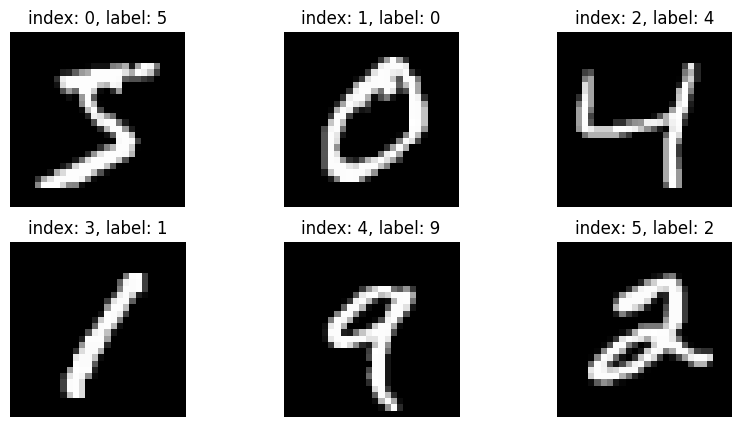

In [6]:
# ilk birkaç örneği görselleştir
plt.figure(figsize = (10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_train[i], cmap = "gray")
    plt.title(f"index: {i}, label: {y_train[i]}")
    plt.axis("off")
plt.show()

In [7]:
# veri setinin normalize edilmesi 0-255 aralığında 0-1 aralığına ölçeklendirme
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1]*x_train.shape[2])).astype("float32")/255 # 70000,28,28 -> 70000, 784
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1]*x_test.shape[2])).astype("float32")/255

In [8]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [9]:
x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [10]:
# etiketleri kategorik hale getir, 0,1,2 ...,9 -> on hot encoding
y_train = to_categorical(y_train, 10) # 10 = sınıf sayisi
y_test = to_categorical(y_test, 10)

In [11]:
# ANN modeli oluşturma
model = Sequential() # base bunun üzerine layer ları ekle

In [12]:
# ilk katman: 512 cell (nöron), relu aktivasyon fonksiyonu, input_size 28*28 = 784
model.add(Dense(512, activation = "relu", input_shape = (28*28,)))

# ikinci katman: 256 cell(nöron), tanh aktivasyon fonksiyonu
model.add(Dense(256, activation = "tanh"))

# output layer: 10 tane olmalı çünkü 10 sınıflı bir sınıflandırma problemi çözüyoruz, activation softmax olmalı
# eğer iki sınıflı çözseydik aktivasyon sigmoid
model.add(Dense(10, activation = "softmax"))
     

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-20 17:53:54.217910: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
# ilk katman: 512 cell, relu aktivasyon fonksiyonu, input_size 28*28 = 784
model.add(Dense(512, activation = "relu", input_shape = (28*28,)))

# ikinci katman: 256 cell, tanh aktivasyon fonksiyonu
model.add(Dense(256, activation = "tanh"))

# output layer: 10 tane olmalı çünkü 10 sınıflı bir sınıflandırma problemi çözüyoruz, activation softmax olmalı
# eğer iki sınıflı çözseydik aktivasyon sigmoid
model.add(Dense(10, activation = "softmax"))

In [14]:
# model derlemesi
# compile --> optimizer, loss ve metrics parametrelerini alır.
model.compile(
    optimizer = "adam", # optimizer algoritması
    loss = "categorical_crossentropy", # kayıp fonksiyonu
    metrics = ["accuracy"] # doğruluk
    )

In [15]:
# callback tanımlaması
# early stopping: validasyon (test veri seti) loss iyileşmiyorsa eğitimi durdur
early_stopping = EarlyStopping(
    monitor = "val_loss", # test setinde ki loss yani kayıp degerini izler
    patience = 5, # 5 iterasyon boyunca validation loss değişmiyorsa durduralım
    restore_best_weights = True # en iyi modelin ağırlıklarını geri yüklesin
    )

### Not: accuracy ve val_accuracy arasındaki fark fazlaysa overfitting gözlemlenir.

In [16]:
# training: 10 epochs, batch size = 60, validasyon seti oranı %20 olsun
# fit --> training demektir.
history = model.fit(
    x_train, y_train, # eğitim veri seti
    epochs = 2, # model toplamda tüm veri setini 10 kere görecek
    batch_size = 60, # veri setini 60 lı parçalara böler ve 1 epoch da 60 ar 60 ar veriyi modele besler
    validation_split = 0.2, # eğitim verisinin %20 si doğrulama olarak kullanılır
    callbacks = [early_stopping]
)

Epoch 1/2
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7251 - loss: 0.7941 - val_accuracy: 0.9604 - val_loss: 0.1506
Epoch 2/2
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9621 - loss: 0.1325 - val_accuracy: 0.9636 - val_loss: 0.1247


In [17]:
# model evaluation, gorsellestirme, model save and load
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test acc: {test_acc}, test loss: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9577 - loss: 0.1507
Test acc: 0.9631999731063843, test loss: 0.12960606813430786


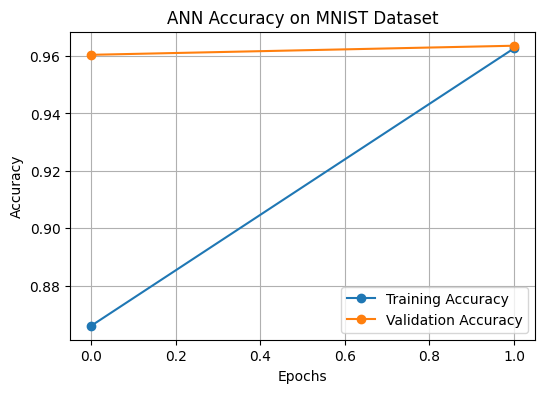

In [18]:
# accuracy training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["accuracy"], marker = "o", label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], marker = "o", label = "Validation Accuracy")
plt.title("ANN Accuracy on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

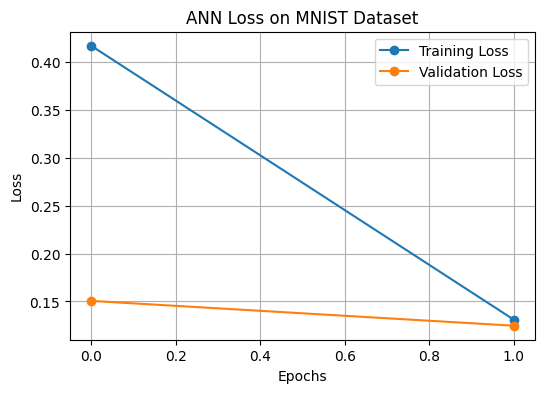

In [19]:
# loss training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["loss"], marker = "o", label = "Training Loss")
plt.plot(history.history["val_loss"], marker = "o", label = "Validation Loss")
plt.title("ANN Loss on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## CNN (Convolutional Neural Network)

PROJENİN AMACI

Bu proje kapsamında, derin öğrenme tabanlı Evrişimsel Sinir Ağları (CNN) kullanılarak
CIFAR-10 veri seti üzerinde çok sınıflı görüntü sınıflandırma problemi çözülmektedir.

VERİ SETİ TANIMI (CIFAR-10)

CIFAR-10 veri seti, 32x32 boyutlarında renkli görüntülerden oluşan 10 sınıflı bir görüntü veri setidir.
Toplam Görüntü Sayısı : 60.000 Eğitim Seti : 50.000 Test Seti : 10.000 Görüntü Boyutu : 32 x 32 x 3 (RGB)

Sınıflar:

Airplane
Automobile
Bird
Cat
Deer
Dog
Frog
Horse
Ship
Truck

PROJE AKIŞ PLANI (PLAN & PROGRAM)

1. Kütüphanelerin içe aktarılması
2. CIFAR-10 veri setinin yüklenmesi
3. Veri görselleştirme
4. Veri ön işleme: Normalizasyon, One-Hot Encoding
5. Veri arttırma (Data Augmentation)
6. CNN mimarisinin oluşturulması
7. Modelin derlenmesi (Compile)
8. Modelin eğitilmesi (Training)
9. Modelin test edilmesi

### Kütüphanaleri ezbere yazmana gerek yok, görünce ne olduğunu bilmelisin.

### Not: Data Augmentation: Veri arttırımıdır. Birçok şekilde veri arttırımı yapılabilir.

### CNN, Görüntü işleme problemlerinde kullanılır. cifar10 ile görüntü sınıflandırma problemiyle uğraşacağız.

In [20]:
# 1. Kütüphanelerin içe aktarılması
# %% veri setini iceriye aktar ve preprocessing: normalizasyon, one-hot encoding
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10 # veri seti
from tensorflow.keras.utils import to_categorical # encoding - OneHotEncoing
from tensorflow.keras.models import Sequential # sirali model
from tensorflow.keras.layers import Conv2D, MaxPooling2D # feature extraction
from tensorflow.keras.layers import Flatten, Dense, Dropout # classification
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator # data augmentation

from sklearn.metrics import classification_report

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


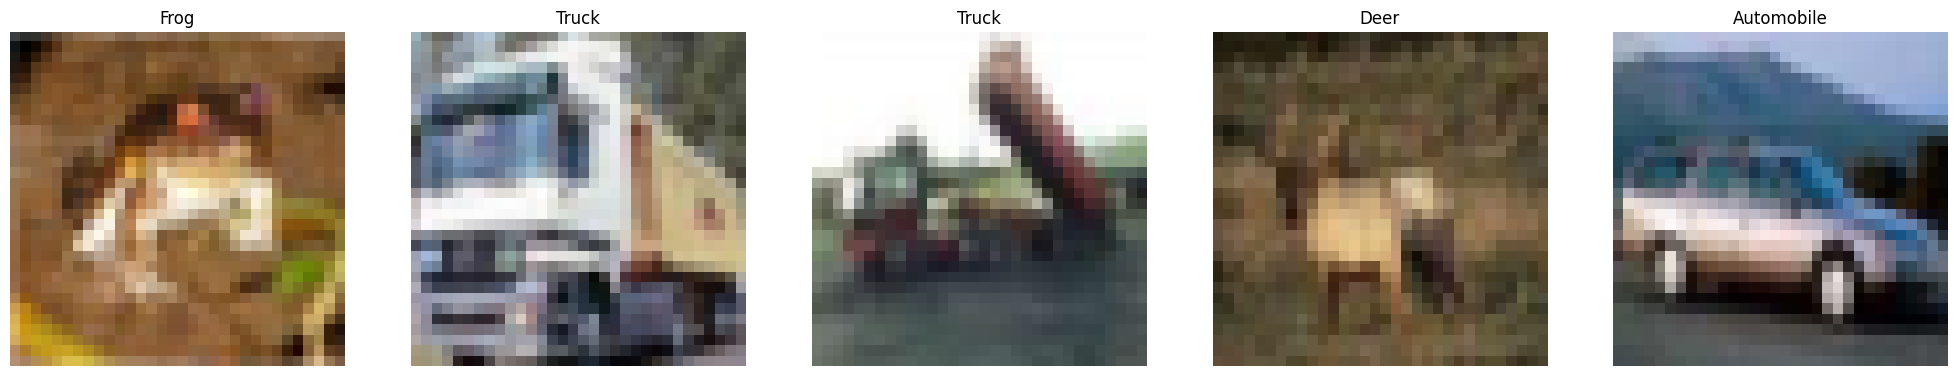

In [21]:
# 2. CIFAR-10 veri setinin yüklenmesi
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 3. Veri görselleştirme
class_labels = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse","Ship","Truck"]

# bazi goruntuleri ve etiketlerini gorsellestir
fig, axes = plt.subplots(1, 5, figsize=(25,20))

for i in range(5):
    axes[i].imshow(x_train[i])
    label = class_labels[y_train[i][0]]
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

In [22]:
# 4. Veri ön işleme: Normalizasyon, One-Hot Encoding
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

# one-hot encoding
y_train= to_categorical(y_train, 10) # 10 class var, bu nedenle 10 yaziyoruz
y_test = to_categorical(y_test, 10)

### Bu adımı ilk kez görüyoruz, veri setinin şekliyle oynayacağız.

In [23]:
# 5. Veri arttırma (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range = 20, # 20 dereceye kadar dondurme saglar
    width_shift_range = 0.2, # goruntuyu yatayda %20 kaydirma
    height_shift_range = 0.2, # goruntuyu dikeyde %20 kaydirma
    shear_range = 0.2, # goruntu uzerinde kaydirma
    zoom_range = 0.2, # goruntuye zoom uygulama
    horizontal_flip = True, # goruntuyu yatayda ters cevirme
    fill_mode = "nearest" # bos alanlari doldurmak icin en yakin pixel degerlerini kullan
    )

datagen.fit(x_train) # data augmentation'i egitim verileri uzerinde uygula

In [24]:
# 6. CNN mimarisinin oluşturulması
model = Sequential()

# Feature Extraction: CONV => RELU => CONV => RELU => POOL => DROPOUT
model.add(Conv2D(32, (3,3), padding = "same", activation = "relu", input_shape = x_train.shape[1:])) # 32 filtre 3x3 kernel
model.add(Conv2D(32, (3,3), activation = "relu"))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.25)) # baglantilarin %25'ini rasgele olarak kapat

# Feature Extraction: CONV => RELU => CONV => RELU => POOL => DROPOUT
model.add(Conv2D(64, (3,3), padding = "same", activation="relu"))
model.add(Conv2D(62, (3,3), activation = "relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Classification: FLATTEN, DENSE, RELU, DROPOUT, DENSE (OUTPUT LAYER)
model.add(Flatten()) # vektor olustur
model.add(Dense(512, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# 7. Modelin derlenmesi (Compile)
model.compile(optimizer = RMSprop(learning_rate = 0.0001, decay= 1e-6),
              loss = "categorical_crossentropy",
                metrics = ["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [26]:
# 8. Modelin eğitilmesi (Training)
history = model.fit(datagen.flow(x_train, y_train, batch_size = 512), # data augmentation uygulanmis veri akisi
          epochs=1, # egitim donem sayisi
          validation_data = (x_test, y_test) # dogrulama seti
          )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.1483 - loss: 2.2407 - val_accuracy: 0.2609 - val_loss: 2.0430


### Not: Değerler iyi değil. İyileştirilebilir.

In [27]:
# 9. Modelin test edilmesi

# modelin test seti uzerinden tahminini yap
y_pred = model.predict(x_test) # y_pred = [0, 1] mesela 0.8 cikarsa %80 olma olasiligi olarak tariflenebilir.
y_pred_class = np.argmax(y_pred, axis=1) # tahmin edilen siniflari al
y_true = np.argmax(y_test, axis = 1)

# classification report hesapla
report = classification_report(y_true, y_pred_class, target_names=class_labels)
print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
              precision    recall  f1-score   support

    Airplane       0.48      0.35      0.40      1000
  Automobile       0.48      0.15      0.23      1000
        Bird       0.12      0.05      0.07      1000
         Cat       0.19      0.04      0.07      1000
        Deer       0.15      0.01      0.02      1000
         Dog       0.29      0.10      0.15      1000
        Frog       0.20      0.89      0.32      1000
       Horse       0.28      0.28      0.28      1000
        Ship       0.32      0.49      0.39      1000
       Truck       0.29      0.26      0.28      1000

    accuracy                           0.26     10000
   macro avg       0.28      0.26      0.22     10000
weighted avg       0.28      0.26      0.22     10000



## RNN

Amaç:

RNN kullanarak duygu analizi (sentiment analizi) gerçekleştirmek
sınıflandırma problemi: restoran yorumları veri seti oluşturalım, etiket: positive (olumlu), negative (olumsuz)

Adımlar:

1. gerekli kütüphanelerin içeri aktarılması
2. restoran yorumları veri seti oluşturma
3. metin ön işleme (preprocessing): tokenization,  4.padding, label encoding (etiket kodlama), train test split
5. embedding: word2vec ile sayısal vektörler oluşturma
6. rnn modeli oluşturma (embedding + simpleRNN + Dense Layer)
8. rnn modelinin derlenmesi ve eğitimi
8. test seti üzerinden modelin değerlendirilmesi

In [28]:
!pip install -q --upgrade gensim smart_open

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 3.4 MB/s eta 0:00:00


In [29]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential # base model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer # tokenlaştırma işlemi

from tensorflow.keras.utils import pad_sequences
from gensim.models import Word2Vec # embedding

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [30]:
# 2. veri seti oluşturma
reviews_data = {
    "text": [
        # ---------- POSITIVE (50) ----------
        "The food was absolutely delicious and perfectly cooked.",
        "Loved the cozy atmosphere and friendly staff.",
        "The pasta tasted fresh and homemade.",
        "Excellent service and wonderful presentation.",
        "Beautiful interior design, I felt very comfortable.",
        "Desserts were heavenly, especially the chocolate mousse.",
        "Very polite staff and quick service.",
        "The burger was juicy and full of flavor.",
        "Great wine selection and relaxing vibe.",
        "The sushi was fresh and beautifully presented.",
        "Amazing experience, we’ll definitely come again.",
        "Loved how clean and elegant the place was.",
        "The seafood platter was generous and tasty.",
        "Everything we tried was top-notch.",
        "Perfect spot for a romantic dinner.",
        "The pizza crust was crispy and flavorful.",
        "Really nice view from the terrace.",
        "Staff was attentive and professional.",
        "Loved the vegan options on the menu.",
        "Fantastic service and quick delivery.",
        "Great cocktails and friendly bartender.",
        "Everything tasted fresh and perfectly seasoned.",
        "Loved every dish we ordered.",
        "The fish was tender and flavorful.",
        "Best steak I’ve had in years!",
        "Absolutely loved the breakfast buffet, everything was fresh and hot.",
        "The waiter was so kind and helpful throughout our meal.",
        "Amazing flavors! The chef really knows what he’s doing.",
        "The ambiance was peaceful, perfect for a family dinner.",
        "Portions were generous and worth the price.",
        "The risotto was creamy and full of flavor.",
        "Loved the live music performance during dinner.",
        "Everything came out on time and nicely plated.",
        "The waitress remembered our names, great personal touch!",
        "The grilled chicken was juicy and well seasoned.",
        "They offered free dessert for our anniversary, so thoughtful!",
        "The restaurant smelled wonderful when we walked in.",
        "The lemonade was freshly made and refreshing.",
        "Clean tables, fast service, and friendly smiles — perfect!",
        "My kids loved the mac and cheese, will definitely return.",
        "The soup was flavorful and comforting.",
        "I appreciated the variety of vegetarian dishes.",
        "Excellent value for money, highly recommended.",
        "The chef customized my order exactly as I asked.",
        "Loved the open terrace view, so relaxing.",
        "Waiters were cheerful and attentive.",
        "Everything was hot and served just right.",
        "The chocolate lava cake was divine!",
        "Beautiful plating and attention to detail.",
        "They even offered complimentary coffee at the end.",

        # ---------- NEGATIVE (50) ----------
        "The waiter was rude and seemed annoyed the whole time.",
        "Our order was wrong and took forever to arrive.",
        "Tables were dirty and the floor was sticky.",
        "The steak was dry and overcooked.",
        "Terrible experience, I won’t be coming back.",
        "The soup was cold and bland.",
        "Overpriced for the small portions they serve.",
        "The music was too loud and annoying.",
        "Waited 45 minutes just to get a salad.",
        "They forgot our drinks twice.",
        "The bread was stale and hard.",
        "The waiter ignored us for most of the night.",
        "They messed up the bill and charged extra.",
        "The chairs were uncomfortable and wobbly.",
        "Worst dining experience ever.",
        "Our food arrived cold and unappetizing.",
        "The salad had no dressing and was wilted.",
        "The restroom was disgusting.",
        "Too expensive for what you get.",
        "Found a hair in my soup.",
        "The fries were soggy and undercooked.",
        "The air conditioning wasn’t working, it was hot.",
        "Too crowded and noisy to enjoy the meal.",
        "They ran out of half the menu.",
        "They charged for water, unbelievable.",
        "The food took over an hour to arrive.",
        "Our table was right next to the restroom, awful smell.",
        "The staff seemed totally unorganized.",
        "My steak was raw in the middle.",
        "The drinks were watered down and tasteless.",
        "Too dark inside, couldn’t even read the menu.",
        "They served cold fries and didn’t replace them.",
        "Music was blasting, couldn’t hear anyone at the table.",
        "The menu looked fancy but the food was disappointing.",
        "They forgot my order completely.",
        "Waited 20 minutes just to get water.",
        "The pasta sauce was way too salty.",
        "Hostess was rude and dismissive.",
        "They seated us near a drafty door, freezing!",
        "No parking available nearby, huge inconvenience.",
        "The chicken was rubbery and bland.",
        "Our dessert never arrived, even after reminding twice.",
        "Service charge added without telling us.",
        "They ran out of napkins halfway through dinner.",
        "Tables were sticky and unclean.",
        "The meat smelled strange, not fresh at all.",
        "Our reservation wasn’t found in the system.",
        "Too expensive for such poor quality food.",
        "They spilled soup on the table and didn’t apologize.",
        "Cold food, bad service, not coming again."
    ],
    "labels": [
        # 50 positive
        *["positive"] * 50,
        # 50 negative
        *["negative"] * 50
    ]
}


### Tokenizer --> Kelimeleri indexlere çevirme

In [31]:
# metin ön işleme
# tokenization
# dataframe e çevir
df = pd.DataFrame(reviews_data)
print(df.head())
tokenizer = Tokenizer() # kelimeleri sayısal indekslere çevirir
tokenizer.fit_on_texts(df["text"]) # kelime sözlüğünü oluşturur
text_sequences = tokenizer.texts_to_sequences(df["text"]) # yorumları sayı dizisine çevirir
word_index = tokenizer.word_index
print(word_index)

                                                text    labels
0  The food was absolutely delicious and perfectl...  positive
1      Loved the cozy atmosphere and friendly staff.  positive
2               The pasta tasted fresh and homemade.  positive
3      Excellent service and wonderful presentation.  positive
4  Beautiful interior design, I felt very comfort...  positive
{'the': 1, 'and': 2, 'was': 3, 'they': 4, 'for': 5, 'our': 6, 'loved': 7, 'were': 8, 'to': 9, 'food': 10, 'service': 11, 'of': 12, 'too': 13, 'fresh': 14, 'everything': 15, 'a': 16, 'in': 17, 'my': 18, 'staff': 19, 'i': 20, 'dinner': 21, 'menu': 22, 'soup': 23, 'cold': 24, 'friendly': 25, 'great': 26, 'experience': 27, 'we': 28, 'perfect': 29, 'flavorful': 30, 'on': 31, 'steak': 32, 'hot': 33, 'waiter': 34, 'so': 35, 'music': 36, 'out': 37, 'tables': 38, 'order': 39, 'just': 40, 'even': 41, 'at': 42, 'get': 43, 'us': 44, 'table': 45, 'absolutely': 46, 'perfectly': 47, 'pasta': 48, 'tasted': 49, 'excellent': 50, 'wo

### Padding: CNN'de görülen görselin etrafına sıfırlar yerleştirmek. Cümle uzunlukları eşit seviyeye getirir.

In [32]:
# padding
"""
max padding uzunluğu = 3

    - test seti üzerinden modelin değerlendirilmesi:
        - test seti üzerinden
        - modelin değerlendirilmesi 0
    - user test
        - user test 0
"""
max_sequence_len = max(len(seq) for seq in text_sequences)
print(max_sequence_len)
X = pad_sequences(text_sequences, maxlen=max_sequence_len) # tüm cümleleri aynı uzunluğa getir
print(f"Giriş verisinini boyutu: {X.shape}") # (100, 10)

10
Giriş verisinini boyutu: (100, 10)


In [33]:
# label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["labels"]) # positive = 1, negative = 0

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)

(80, 10)


### Embedding --> Indexeri boyutlandırma

In [34]:
# 4. embedding
sentences = [text.split() for text in df["text"]]
# word2vec modeli eğit
embedding_dim = 50
word2vec_model = Word2Vec(sentences, vector_size=embedding_dim, window=5, min_count=1)

# embedding matrisi
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, idx in word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[idx] = word2vec_model.wv[word]
print(f"embedding matris: {embedding_matrix}")

embedding matris: [[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.01542055 -0.01904649 -0.00063714 ... -0.00532242 -0.01879257
   0.00912681]
 [-0.00135636  0.00037204  0.00984608 ...  0.01858133  0.01012342
   0.01841119]
 ...
 [-0.00235903 -0.00474097 -0.00369994 ... -0.00143787  0.00182739
   0.01360518]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.00547641  0.00019958  0.00402067 ... -0.01983353 -0.01956106
   0.002188  ]]


In [35]:
# 5. rnn modeli oluşturma
model = Sequential()

In [36]:
# modele embedding katmanı eklenmesi
model.add(Embedding(
    input_dim = len(word_index) + 1, # toplam kelime sayısı + 1 (yani sıfır değeri)
    output_dim = embedding_dim, # embedding boyutu (50)
    weights = [embedding_matrix], # önceden eğitilmiş word2vec embedding matrisi
    input_length = max_sequence_len, # cümlelerin max uzunluğu (10)
    trainable = False # embedding ağırlıkları sabit kalacak
    )
)

# rnn katmanı: units = gizli katman sayısı, return_sequences = sadece son çıktıyı return eder
model.add(SimpleRNN(units = 50, return_sequences = False))

# output katmanı
model.add(Dense(1, activation = "sigmoid")) # 2 sınıflı bir sınıflandırma problemi için sigmoid

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [37]:
# compile (derleme)
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

### accuracy artarken val_acc artmadı, bu training'te overfitting'e doğru gittiğimizi gösterir.

In [38]:
# 6. training
model.fit(
    X_train, y_train,
    epochs = 10, # eğitim tekrar sayısı
    batch_size = 2, # mini batch boyutu
    validation_data = (X_test, y_test) # test seti ile doğrulama
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4322 - loss: 0.6954 - val_accuracy: 0.5000 - val_loss: 0.6915
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6044 - loss: 0.6886 - val_accuracy: 0.6000 - val_loss: 0.6860
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8001 - loss: 0.6483 - val_accuracy: 0.6000 - val_loss: 0.6705
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8090 - loss: 0.6121 - val_accuracy: 0.7000 - val_loss: 0.6343
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7214 - loss: 0.5791 - val_accuracy: 0.7000 - val_loss: 0.6376
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7726 - loss: 0.4911 - val_accuracy: 0.7000 - val_loss: 0.5833
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8528 - loss: 0.4199 - val_accuracy: 0.6000 - val_loss: 0.7535
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8929 - loss: 0.2889 - val_accuracy: 0.5000 - val_loss

In [39]:
# 7. test veri seti ile değerlendirme
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test acc: {test_acc}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.7500 - loss: 0.5996
Test loss: 0.5995596647262573
Test acc: 0.75


## LSTM

Amaç:

1. 20 farklı haber kategorisinden oluşan 20 Newsgroup veri setini kullanarak metin sınıflandırma
Veri seti:

sklearn: 20 newsgroup veri seti
20 farklı haber kategorisi: teknoloji, spor, uzay, sağlık vb.
toplam metin sayısı 18k

Adımlar:

1. gerekli kütüphanelerin içeriye aktarılması
2. veri setinin yüklenmesi
3. tokenization kelimelerin sayısal indekslere çevrilmesi.
4. padding (tüm metinlerin aynı uzunluğa getirilmesi)
5. label encoding
6. eğitim ve test ayrımı
7. LSTM modelinin oluşturulması
8. LSTM modeli eğitimi
9. LSTM testtleri
10. Accuracy ve Loss grafiklerinin çizdirilmesi

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
# 2. veri setinin yüklenmesi
newsgroup = fetch_20newsgroups(subset = "all")
X = newsgroup.data # metinler
y = newsgroup.target # metinlere karşılık gelen etiketler
# kaç epochluk training yaptınız ve accuracy ne çıktı?

In [42]:
# 3 - 4 tokenization ve padding
tokenizer = Tokenizer(num_words = 10000) # en çok kullanılan 10k kelimeyi al
tokenizer.fit_on_texts(X)
X_sequences = tokenizer.texts_to_sequences(X)
X_padded = pad_sequences(X_sequences, maxlen = 100)
     

In [43]:
X_padded.shape

(18846, 100)

In [44]:
y

array([10,  3, 17, ...,  3,  1,  7])

In [45]:
# 5. label encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([10,  3, 17, ...,  3,  1,  7])

In [46]:
# 6. train test split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y , test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)

(15076, 100)
(3770, 100)


In [47]:
# 7. LSTM modelinin oluşturulması
model = Sequential()

model.add(Embedding(
    input_dim = 10000, # sözlükteki kelime sayısı
    output_dim = 64, # kelime vektörlerinin boyutu
    input_length = 100
))

model.add(LSTM(
    units = 8, # cell sayısı
    return_sequences = False
))

model.add(Dropout(0.5))

model.add(Dense(20, activation = "softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [48]:
# model compile
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [49]:
early_stopping = EarlyStopping(monitor = "val_accuracy", patience = 5, restore_best_weights=True)

In [50]:
history = model.fit(
    X_train, y_train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.3,
    callbacks = [early_stopping]
                    )

Epoch 1/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.0758 - loss: 2.9537 - val_accuracy: 0.1397 - val_loss: 2.7290
Epoch 2/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.1470 - loss: 2.6628 - val_accuracy: 0.2213 - val_loss: 2.5139
Epoch 3/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.2103 - loss: 2.4283 - val_accuracy: 0.2865 - val_loss: 2.3109
Epoch 4/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.2506 - loss: 2.2136 - val_accuracy: 0.3305 - val_loss: 2.2016
Epoch 5/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.2981 - loss: 2.0649 - val_accuracy: 0.3595 - val_loss: 2.0803
Epoch 6/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.3181 - loss: 1.9230 - val_accuracy: 0.3796 - val_loss: 2.0281
Epoch 7/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.3270 - loss: 1.8279 - val_accuracy: 0.3984 - val_loss: 1.9983
Epoch 8/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.3626 - loss: 1.7461 - 

In [51]:
# 8. test veri seti ile test
loss, accuracy = model.evaluate(X_test, y_test)   

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5531 - loss: 1.9819


In [52]:
accuracy

0.558355450630188

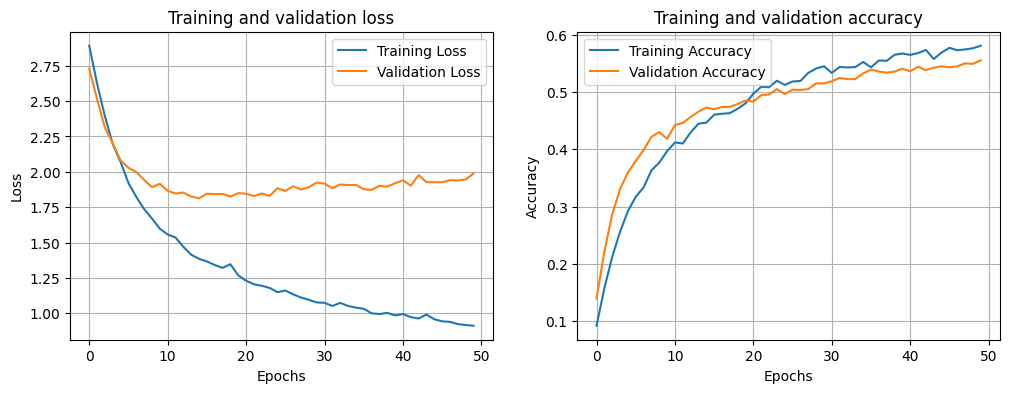

In [53]:
# 9. accuracy ve loss değerlerinin çizdirilmesi
plt.figure(figsize = (12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()